In [2]:
import zipfile
'''import pandas as pd
import numpy as np'''

import matplotlib.pyplot as plt
'''import seaborn as sns'''
import os

#import tensorflow as tf
from tensorflow.keras.preprocessing import image
#from tensorflow.keras.losses import SparseCategoricalCrossentropy

from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")


2025-11-18 21:48:13.862470: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-18 21:48:14.156331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 21:48:32.419654: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 21:48:43.701331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [3]:
# Extraer el archivo .zip

with zipfile.ZipFile("../data/raw/dogs-vs-cats.zip", 'r') as zip_ref:
    zip_ref.extractall("../data/raw/dataset")

Esto crea la carpeta /dataset/ con dentro /train/ que contiene todas las imágenes

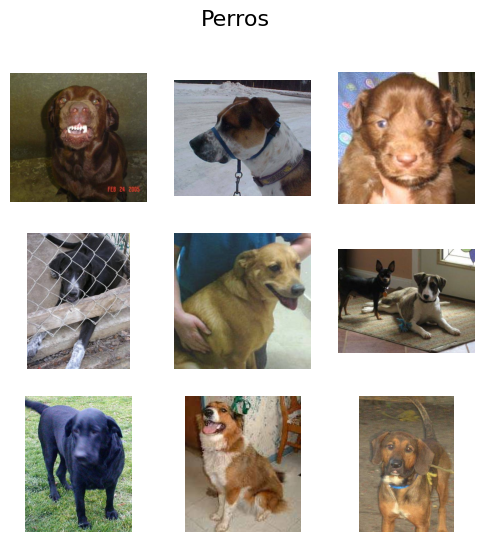

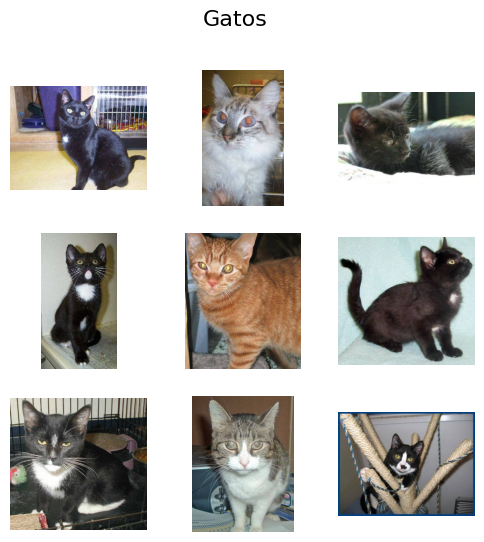

In [ ]:
# Visualizar 9 imagenes de perros
folder = "../data/raw/dataset/dogs-vs-cats/train"
def show_images(file_list, folder, title):
    plt.figure(figsize=(6,6))
    for i, f in enumerate(file_list):
        img_path = os.path.join(folder, f)
        img = image.load_img(img_path)       
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show


dog_images = [f for f in os.listdir(folder) if f.startswith("dog")][:9]     # Busca los archivos que empiezan por "dog"
cat_images = [f for f in os.listdir(folder) if f.startswith("cat")][:9]     # o "cat" y coge los primeros 9 de cada clase.

# 9 perros
show_images(dog_images, folder, "Perros")

# 9 gatos
show_images(cat_images, folder, "Gatos")

In [5]:
import psutil
# Comprobamos cuántos GB de RAM tenemos

ram_bytes = psutil.virtual_memory().total
ram_gb = ram_bytes / (1024**3)
print(f"Tienes {ram_gb:.2f} GB de RAM")

Tienes 7.76 GB de RAM


Como **no** tengo más de **12 gigabytes de RAM**, cargaremos las imágenes progresivamente usando la clase Keras **ImageDataGenerator** y la función **flow_from_directory()**. Esto será más lento de ejecutar, pero se ejecutará en hardware de menor capacidad. Esta función prefiere que los datos se dividan en directorios train y test separados, y debajo de cada directorio para tener un subdirectorio para cada clase

In [6]:
base_dir = "../data/processed" # carpeta donde organizamos train y test

for split in ["train", "test"]:
    for cls in ["cats", "dogs"]:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

Hemos creado las carpetas:

../data/processed/train/cats

../data/processed/train/dogs

../data/processed/test/cats

../data/processed/test/dogs

In [7]:
import shutil
import random

# Carpeta de origen

folder = "../data/raw/dataset/dogs-vs-cats/train"

# Carpetas de destino

train_cats = "../data/processed/train/cats"
train_dogs = "../data/processed/train/dogs"
test_cats = "../data/processed/test/cats"
test_dogs = "../data/processed/test/dogs"


# Separar los nombres de archivos por cats o dogs

cats = [f for f in os.listdir(folder) if f.startswith("cat")]   # Crea una lista de archivos que tienen 'cat' en el nombre.
dogs = [f for f in os.listdir(folder) if f.startswith("dog")]   # Crea una lista de archivos que tienen 'dog' en el nombre.

# Dividir en train/test con sklearn
cats_train, cats_test = train_test_split(cats, train_size=0.8, random_state=42)
dogs_train, dogs_test = train_test_split(dogs, train_size=0.8, random_state=42)

# Copiar gatos  
for f in cats_train:
    shutil.copy(os.path.join(folder, f), train_cats)
for f in cats_test:
    shutil.copy(os.path.join(folder, f), test_cats)

# Copiar perros
for f in dogs_train:
    shutil.copy(os.path.join(folder, f), train_dogs)
for f in dogs_test:
    shutil.copy(os.path.join(folder, f), test_dogs)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Generador para train y test
train_datagen = ImageDataGenerator(rescale=1/255)   # escalamos para obtener valores entre 0 y 1
test_datagen = ImageDataGenerator(rescale=1/255)

In [9]:
# Cargar imágenes desde las carpetas
train_dir = "../data/processed/train"
test_dir = "../data/processed/test"

trdata = train_datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),     # redimensionar las imagenes
    batch_size=32,
    class_mode="binary"
)

tsdata = test_datagen.flow_from_directory(
    test_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode="binary"
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [10]:
print(trdata.class_indices)

{'cats': 0, 'dogs': 1}


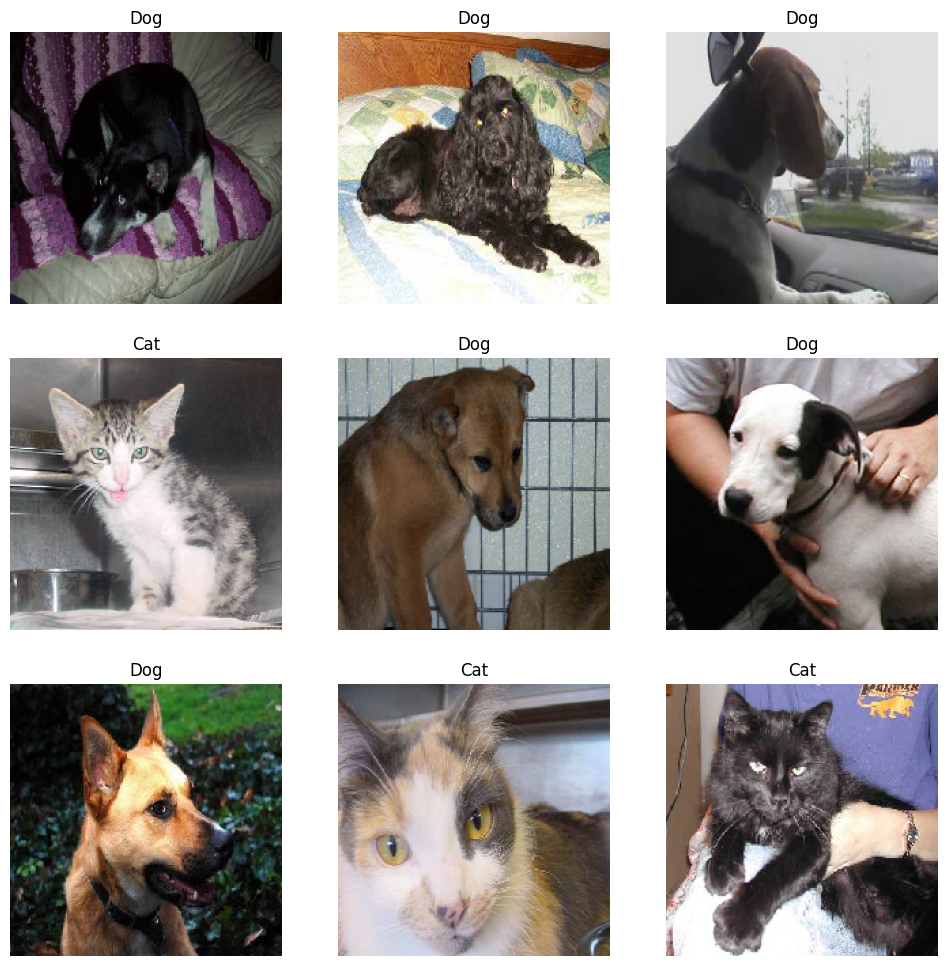

In [11]:
# Obtener un batch del generador de entrenamiento
images, labels = next(trdata)

plt.figure(figsize=(12, 12))

for i in range(9):  # mostrar 9 imágenes
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.show()